In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [ ]:
#a)
# Define symbols
t, C1, C2, r1, r2 = sp.symbols('t C1 C2 r1 r2')

# Define the general solution
x_t = C1*sp.exp(r1*t) + C2*sp.exp(r2*t)

# Display the general solution
print("General Solution for x(t):")
display(x_t)

General Solution for x(t):


C1*exp(r1*t) + C2*exp(r2*t)

General solution (symbolic):


Eq(x(t), (C1*sin(1.98431348329844*t) + C2*cos(1.98431348329844*t))*exp(-0.25*t))

<ipython-input-8-b62925b7f144>:19: RuntimeWarning: invalid value encountered in sqrt
  r1 = (-c + np.sqrt(c**2 - 4*m*k))/(2*m)
<ipython-input-8-b62925b7f144>:20: RuntimeWarning: invalid value encountered in sqrt
  r2 = (-c - np.sqrt(c**2 - 4*m*k))/(2*m)


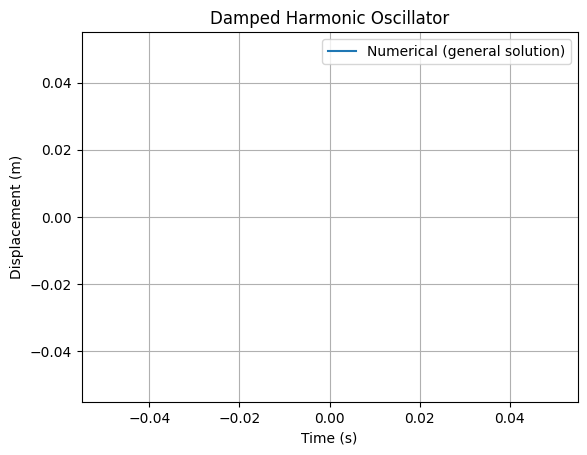

In [ ]:
# Constants
m = 1  # Mass
c = 0.5  # Damping coefficient
k = 4  # Spring constant

# Initial conditions
x0 = 2  # Initial displacement
v0 = 1  # Initial velocity

# Symbolic solution using SymPy
t = sp.symbols("t")
x = sp.Function("x")(t)
diff_eq = sp.Eq(m*sp.diff(x, t, 2) + c*sp.diff(x, t) + k*x, 0)
general_solution = sp.dsolve(diff_eq)
print("General solution (symbolic):")
display(general_solution)

# Numerical solution using the general solution
r1 = (-c + np.sqrt(c**2 - 4*m*k))/(2*m)
r2 = (-c - np.sqrt(c**2 - 4*m*k))/(2*m)
C1 = (x0 - (v0 + r2*x0)/(r1 - r2)) / (r1 - r2)
C2 = x0 - C1

t_vals = np.linspace(0, 20, 200)
x_vals_numerical = C1*np.exp(r1*t_vals) + C2*np.exp(r2*t_vals)


# Plot the results
plt.plot(t_vals, x_vals_numerical, label="Numerical (general solution)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Damped Harmonic Oscillator")
plt.grid()
plt.legend()
plt.show()

Using euler's method

General solution (symbolic):


Eq(x(t), (C1*sin(1.98431348329844*t) + C2*cos(1.98431348329844*t))*exp(-0.25*t))

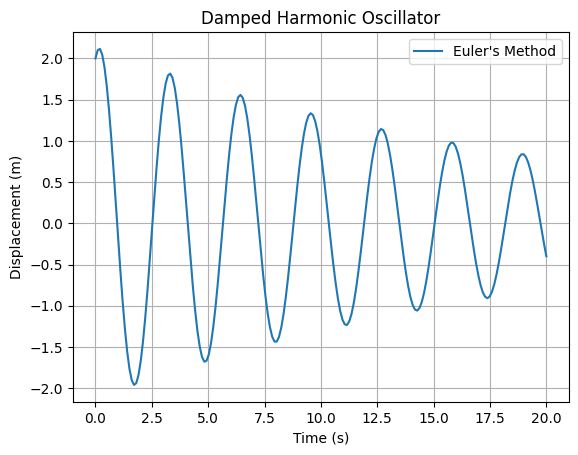

In [ ]:
#b)
# Constants
m = 1  # Mass
c = 0.5  # Damping coefficient
k = 4  # Spring constant

# Initial conditions
x0 = 2  # Initial displacement
v0 = 1  # Initial velocity

# Symbolic solution using SymPy
t = sp.symbols("t")
x = sp.Function("x")(t)
diff_eq = sp.Eq(m*sp.diff(x, t, 2) + c*sp.diff(x, t) + k*x, 0)
general_solution = sp.dsolve(diff_eq)
print("General solution (symbolic):")
display(general_solution)

# Euler's method implementation
def dx_dt(x, v):
    return v

def dv_dt(x, v):
    return -(c/m)*v - (k/m)*x

n = 200
h = (20 - 0) / (n - 1)
t_vals_euler = np.linspace(0, 20, n)
x_vals_euler = np.zeros(n)
v_vals_euler = np.zeros(n)

x_vals_euler[0] = x0
v_vals_euler[0] = v0

for i in range(1, n):
    x_vals_euler[i] = x_vals_euler[i-1] + h * dx_dt(x_vals_euler[i-1], v_vals_euler[i-1])
    v_vals_euler[i] = v_vals_euler[i-1] + h * dv_dt(x_vals_euler[i-1], v_vals_euler[i-1])

plt.plot(t_vals_euler, x_vals_euler, label="Euler's Method")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Damped Harmonic Oscillator")
plt.grid()
plt.legend()
plt.show()

In [ ]:
#This part is from AI

# Interpretation of the graph

# - Damping coefficient (c):
#      - Controls the rate of decay of oscillations.
#      - Higher c leads to faster decay.
#      - Observe the graph's curvature to visualize this effect.

# - Roots of characteristic equation (r1, r2):
#      - Determine the nature of oscillations:
#          - Real and distinct: Overdamped (oscillations die out without crossing zero).
#          - Real and equal: Critically damped (oscillations decay to zero as quickly as possible).
#          - Complex conjugates: Underdamped (oscillations decay with a sinusoidal pattern).

# - Notable features in this case:
#      - Initial displacement: Determines the starting point of the graph (2 in this case).
#      - Initial velocity: Affects the slope of the graph at t=0 (1 in this case).
#      - Decay rate: Influenced by damping coefficient (0.5 in this case).
#      - Frequency: Determined by spring constant and mass (4 and 1 in this case).